<div style="font-family: Arial, sans-serif; background-color: #f8f9fa; padding: 20px; border-radius: 10px;">
  <img src="https://sigmoidal.ai/wp-content/uploads/2024/09/Academia-Sigmoidal-Light.png" alt="Academia Sigmoidal" width="250">
  <h1 style="color: #007bff; font-size: 24px;">Bootcamp de Visão Computacional com Drones</h1>
  <h3 style="color: #343a40; font-size: 20px;">Projeto 4: Adaptar o detector às imagens aéreas</h3>
  <p style="color: #6c757d; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>


# Adaptar o detector às imagens aéreas

Vamos ajustar o YOLO11n com o treino, selecionar o checkpoint pela validação e avaliar a contagem com o mesmo protocolo do baseline. O treinamento curto é uma hipótese experimental; uma melhoria não está garantida.

Este notebook é independente: os dados necessários acompanham o repositório. No Colab, selecione **Copiar para o Drive** e execute as células na ordem. Selecione uma GPU em Ambiente de execução > Alterar tipo de ambiente de execução.

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/carlosfab/bootcamp-visao-computacional-drones/blob/codex/projeto-4-gado/projeto-4/02_fine_tuning.ipynb)


## Ambiente

A primeira célula obtém os arquivos da versão do projeto e instala as dependências. O PyTorch fornecido pelo ambiente será preservado; sua versão será registrada. Se já importou bibliotecas antes desta instalação, reinicie o ambiente e execute novamente desde o início.

Os arquivos de trabalho ficam em `dados/`, `pesos/` e `resultados/`. As pastas de métricas e figuras têm nomes fixos e seus arquivos são atualizados ao reexecutar. Antes de repetir o experimento ou encerrar o Colab, baixe o ZIP seguindo as instruções ao final.


In [1]:
from pathlib import Path
import os
import subprocess
import sys
if not Path("suporte").is_dir():
    destino = Path("/content/bootcamp-gado")
    if not destino.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--filter=blob:none", "--sparse", "--branch", "codex/projeto-4-gado",
                        "https://github.com/carlosfab/bootcamp-visao-computacional-drones.git", str(destino)], check=True)
    subprocess.run(["git", "-C", str(destino), "sparse-checkout", "set", "projeto-4"], check=True)
    os.chdir(destino / "projeto-4")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], returncode=0)

In [2]:
import json
import hashlib
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from suporte.preparar_dados import obter_dados
from suporte.experimento import inventario, ler_caixas, desenhar
plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 12,
                     "font.family": "sans-serif", "axes.grid": False})


A semente controla parte da aleatoriedade, mas versões, hardware e operações numéricas também influenciam o resultado. O registro abaixo identifica o ambiente desta execução, sem prometer identidade bit a bit entre CPU e GPU.


In [3]:
import torch
from ultralytics import YOLO
from importlib.metadata import version
from suporte.experimento import inferir, calibrar, salvar_resultado
from suporte.contagem import evaluate_predictions
DISPOSITIVO = 0 if torch.cuda.is_available() else "cpu"
print("Dispositivo:", DISPOSITIVO)


Dispositivo: 0


In [4]:
SAIDA = Path("resultados/fine_tuning")
SAIDA.mkdir(parents=True, exist_ok=True)
pacotes = ["numpy", "pandas", "matplotlib", "Pillow", "ultralytics", "torch"]
ambiente = {nome: version(nome) for nome in pacotes}
ambiente["python"] = platform.python_version()
ambiente["sistema"] = platform.platform()
ambiente["dispositivo"] = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
(SAIDA / "ambiente.json").write_text(json.dumps(ambiente, indent=2))
display(ambiente)


{'numpy': '2.2.6',
 'pandas': '2.2.3',
 'matplotlib': '3.9.4',
 'Pillow': '11.3.0',
 'ultralytics': '8.3.203',
 'torch': '2.11.0+cu128',
 'python': '3.13.15',
 'sistema': 'Linux-6.6.122+-x86_64-with-glibc2.39',
 'dispositivo': 'Tesla T4'}

## Dados e partições

O recorte didático contém **300 imagens** de bovinos a pasto: 180 de treino, 60 de validação e 60 de teste. As imagens derivam do ICAERUS v2, com lado maior limitado a 2048 pixels e anotações YOLO de uma classe, `cow`. A atribuição e a licença CC BY 4.0 acompanham os dados.

Treino e validação usam Mauron e Jalogny em datas separadas. O teste usa Derval, uma fazenda ausente do desenvolvimento. Datas e voos não atravessam partições, mas os animais não têm identificadores individuais. A avaliação mede contagem **por imagem**, não um censo de indivíduos únicos.


In [5]:
RAIZ = obter_dados()
tabela = inventario(RAIZ)
manifesto = json.loads((RAIZ / "manifesto.json").read_text())
treino = tabela[tabela["split"] == "train"].copy()
validacao = tabela[tabela["split"] == "val"].copy()
teste = tabela[tabela["split"] == "test"].copy()
assert [len(treino), len(validacao), len(teste)] == [180, 60, 60]
print("Imagens de treino, validação e teste:", len(treino), len(validacao), len(teste))


Imagens de treino, validação e teste: 180 60 60


## Configuração antes do treinamento

Usaremos 25 épocas, batch de 8 imagens, entrada de 640 pixels e semente 42. A GPU é recomendada; a CPU pode executar, mas seu tempo não representa o percurso planejado para aula. Não instalamos outra versão de PyTorch sobre a fornecida pelo Colab.

O diretório de treino deve ser novo. Para investigar outra configuração, escolha outro `name` e registre a mudança antes de consultar o teste. Isso protege a pasta de treino; a pasta fixa `resultados/fine_tuning` de métricas e figuras será atualizada. Baixe o ZIP da execução anterior antes de reexecutar desde o início. A semente não garante resultados idênticos entre diferentes ambientes.


In [6]:
modelo = YOLO("yolo11n.pt")
cfg = dict(data=str(RAIZ.relative_to(Path.cwd()) / "data.yaml"), epochs=25, batch=8, imgsz=640,
           seed=42, workers=2, deterministic=True, cache=False, plots=False,
           device=DISPOSITIVO, project="resultados/treino", name="gado", exist_ok=False)
assert not Path(cfg["project"], cfg["name"]).exists(), "Use outro nome para uma nova execução."
(SAIDA / "configuracao_treino.json").write_text(json.dumps(cfg, indent=2))
display(cfg)


{'data': 'dados/gado/data.yaml',
 'epochs': 25,
 'batch': 8,
 'imgsz': 640,
 'seed': 42,
 'workers': 2,
 'deterministic': True,
 'cache': False,
 'plots': False,
 'device': 0,
 'project': 'resultados/treino',
 'name': 'gado',
 'exist_ok': False}

**Fine-tuning** parte dos pesos genéricos e os atualiza com as imagens do domínio. A validação acompanha o treinamento e determina `best.pt`; o teste não participa da seleção. Os argumentos completos usados pela biblioteca também ficam registrados em `args.yaml` dentro da execução.

Não interrompa a célula para escolher uma época que parece boa no teste. Se o runtime cair, trate os arquivos existentes como um treino possivelmente incompleto e preserve-os para diagnóstico.


In [7]:
from time import perf_counter
inicio = perf_counter()
modelo.train(**cfg)
segundos_treino = perf_counter() - inicio
pasta_treino = Path(modelo.trainer.save_dir)
melhor = Path(modelo.trainer.best)
assert melhor.is_file(), "O treinamento não produziu best.pt."
print("Treino concluído em segundos:", round(segundos_treino, 1))
print("Checkpoint:", melhor)


New https://pypi.org/project/ultralytics/8.4.163 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.3.203 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)


engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dados/gado/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=gado, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=False, pose=12.0, pretrained=True, profile=False, project=resultados/treino, rect=False, resume=False, retin

Overriding model.yaml nc=80 with nc=1



                   from  n    params  module                                       arguments                     


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 11.6it/s 0.3s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 11.6it/s 0.3s

                   all         60        278      0.524      0.313      0.282     0.0873


Speed: 0.2ms preprocess, 2.4ms inference, 0.0ms loss, 1.9ms postprocess per image


Treino concluído em segundos: 262.2
Checkpoint: /content/bootcamp-gado/projeto-4/resultados/treino/gado/weights/best.pt


## Ler as curvas de treinamento

A perda de localização de treino e a de validação ajudam a investigar o ajuste. Queda da perda de treino sem melhora na validação pode indicar que o modelo está se adaptando demais à amostra. As curvas não autorizam escolher parâmetros pelo teste.


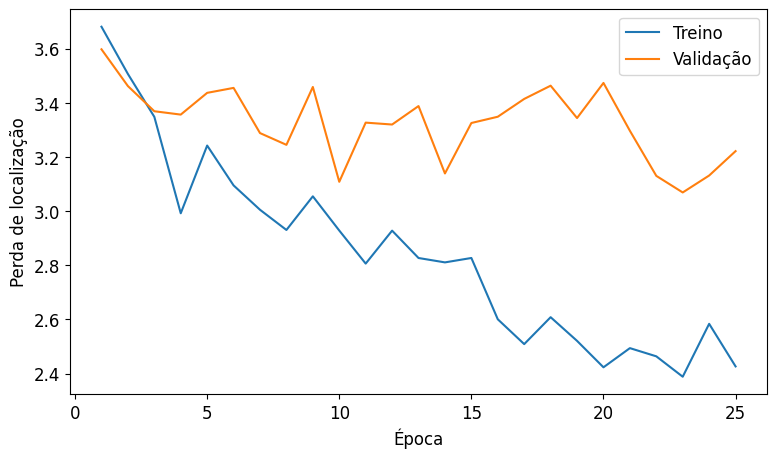

In [8]:
historico = pd.read_csv(pasta_treino / "results.csv")
historico.columns = historico.columns.str.strip()
plt.plot(historico["epoch"], historico["train/box_loss"], label="Treino")
plt.plot(historico["epoch"], historico["val/box_loss"], label="Validação")
plt.xlabel("Época")
plt.ylabel("Perda de localização")
plt.legend()
plt.show()


O registro de conclusão associa o checkpoint aos bytes dos pesos e ao ambiente. Essa identidade permite distinguir seu treinamento de um peso de referência distribuído com o projeto. O arquivo só é gravado depois do retorno normal de `train()`.


In [9]:
conclusao = {"weights": str(melhor.resolve().relative_to(Path.cwd())), "weights_sha256": hashlib.sha256(melhor.read_bytes()).hexdigest(),
             "epochs_completed": len(historico), "seconds": segundos_treino,
             "checkpoint_selection": "best.pt selecionado pela validação durante train()",
             "initial_weights_sha256": hashlib.sha256(Path("yolo11n.pt").read_bytes()).hexdigest(),
             "manifest_sha256": hashlib.sha256((RAIZ / "manifesto.json").read_bytes()).hexdigest()}
(SAIDA / "treinamento_concluido.json").write_text(json.dumps(conclusao, indent=2))
display(conclusao)
ajustado = YOLO(str(melhor))
display(ajustado.names)


{'weights': 'resultados/treino/gado/weights/best.pt',
 'weights_sha256': 'f23ef5633831b70ec604d999290a2029744c754cebc11e11f461d46fd540e674',
 'epochs_completed': 25,
 'seconds': 262.2106829850002,
 'checkpoint_selection': 'best.pt selecionado pela validação durante train()',
 'initial_weights_sha256': '0ebbc80d4a7680d14987a577cd21342b65ecfd94632bd9a8da63ae6417644ee1',
 'manifest_sha256': '353aaa65c5d6faba80e1ce98e0d04779b347ec3ac85b86c19b3bfd8926eb136c'}

{0: 'cow'}

## Calibrar o modelo ajustado

A escala das confianças pode mudar após o treinamento. Escolheremos o limiar novamente na validação, pela mesma regra do baseline: maior F1; em empate, menor MAE e maior limiar. Entrada e regra de associação permanecem iguais.


In [10]:
previsoes_val = inferir(ajustado, validacao, device=DISPOSITIVO)
limiar, calibracao = calibrar(previsoes_val)
calibracao.to_csv(SAIDA / "calibracao.csv", index=False)
display(calibracao[["threshold", "precision", "recall", "f1", "mae"]])
print("Limiar congelado:", limiar)
salvar_resultado(SAIDA / "val", previsoes_val, limiar)


,threshold,precision,recall,f1,mae
0,0.05,0.263514,0.420863,0.324100,4.066667
1,0.10,0.383803,0.392086,0.387900,2.166667
2,0.15,0.462264,0.352518,0.400000,2.300000
3,0.20,0.547619,0.330935,0.412556,2.766667
4,0.25,0.602837,0.305755,0.405728,3.016667
5,0.30,0.609756,0.269784,0.374065,3.216667
6,0.40,0.705128,0.197842,0.308989,3.766667
7,0.50,0.790698,0.122302,0.211838,4.116667
8,0.60,0.800000,0.071942,0.132013,4.350000
9,0.70,0.714286,0.035971,0.068493,4.500000


Limiar congelado: 0.2


{'tp': 92,
 'fp': 76,
 'fn': 186,
 'precision': 0.5476190476190477,
 'recall': 0.33093525179856115,
 'f1': 0.4125560538116592,
 'n_images': 60,
 'mae': 2.7666666666666666,
 'rmse': 5.531726674375733,
 'bias': -1.8333333333333333,
 'exact_accuracy': 0.5833333333333334,
 'exact_match_count': 35,
 'conf_threshold': 0.2,
 'iou_threshold': 0.5,
 'by_presence': {'positive': {'tp': 92,
   'fp': 52,
   'fn': 186,
   'precision': 0.6388888888888888,
   'recall': 0.33093525179856115,
   'f1': 0.43601895734597157,
   'n_images': 18,
   'mae': 7.888888888888889,
   'rmse': 9.7182531580755,
   'bias': -7.444444444444445,
   'exact_accuracy': 0.05555555555555555,
   'exact_match_count': 1,
   'conf_threshold': 0.2,
   'iou_threshold': 0.5},
  'negative': {'tp': 0,
   'fp': 24,
   'fn': 0,
   'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'n_images': 42,
   'mae': 0.5714285714285714,
   'rmse': 1.7994708216848747,
   'bias': 0.5714285714285714,
   'exact_accuracy': 0.8095238095238095,
   'exact

Salvamos a configuração de inferência antes da avaliação final. Reutilizar o teste entre os métodos planejados permite comparação direta; mudar o treinamento depois de examinar esse teste seria um novo ciclo de desenvolvimento.


In [11]:
avaliacao = {"weights_sha256": conclusao["weights_sha256"], "conf": limiar,
             "imgsz": 640, "iou_match": 0.5, "tiled": False,
             "selecao": "F1 val; empate por menor MAE e maior confiança"}
(SAIDA / "configuracao_avaliacao.json").write_text(json.dumps(avaliacao, indent=2))
previsoes_teste = inferir(ajustado, teste, device=DISPOSITIVO)
resumo = salvar_resultado(SAIDA / "test", previsoes_teste, limiar)
chaves = ["n_images", "precision", "recall", "f1", "mae", "rmse", "bias", "exact_accuracy"]
display(pd.Series({chave: resumo[chave] for chave in chaves}, name="Fine-tuning"))
display(resumo["by_presence"])


,Fine-tuning
n_images,60.000000
precision,0.200000
recall,0.054054
f1,0.085106
mae,1.683333
rmse,3.676502
bias,-1.350000
exact_accuracy,0.616667


{'positive': {'tp': 6,
  'fp': 17,
  'fn': 105,
  'precision': 0.2608695652173913,
  'recall': 0.05405405405405406,
  'f1': 0.08955223880597014,
  'n_images': 20,
  'mae': 4.7,
  'rmse': 6.316644678941502,
  'bias': -4.4,
  'exact_accuracy': 0.1,
  'exact_match_count': 2,
  'conf_threshold': 0.2,
  'iou_threshold': 0.5},
 'negative': {'tp': 0,
  'fp': 7,
  'fn': 0,
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'n_images': 40,
  'mae': 0.175,
  'rmse': 0.570087712549569,
  'bias': 0.175,
  'exact_accuracy': 0.875,
  'exact_match_count': 35,
  'conf_threshold': 0.2,
  'iou_threshold': 0.5,
  'false_positive_image_rate': 0.125}}

## Comparar com a referência genérica

Se o baseline foi executado neste mesmo diretório, a tabela abaixo reúne seus resultados. Caso contrário, o notebook continua independente e apresenta apenas o treino atual; execute o notebook do baseline e reúna os arquivos ao preparar a entrega.

Compare as mesmas imagens, versões e regras. Um F1 maior não implica necessariamente um MAE menor, pois omissões e falsos positivos podem se compensar na contagem.

Este é o primeiro experimento: **pesos iniciais versus pesos ajustados**, com arquitetura e inferência mantidas. Identifique cada linha do relatório pelo hash dos pesos. No notebook seguinte, o segundo experimento usa um checkpoint de referência em imagem inteira e recortes; o peso de referência pode ser diferente do seu treino. Não atribua uma diferença entre esses checkpoints apenas aos recortes.


In [12]:
comparacao = {"fine_tuning": {chave: resumo[chave] for chave in chaves}}
arquivo_baseline = Path("resultados/baseline/test/resumo.json")
if arquivo_baseline.exists():
    cfg_baseline = json.loads(Path("resultados/baseline/configuracao.json").read_text())
    assert cfg_baseline["manifest_sha256"] == conclusao["manifest_sha256"], "Baseline usa outros dados."
    baseline = json.loads(arquivo_baseline.read_text())
    comparacao["baseline"] = {chave: baseline[chave] for chave in chaves}
tabela_comparacao = pd.DataFrame.from_dict(comparacao, orient="index")
tabela_comparacao.to_csv(SAIDA / "comparacao.csv")
display(tabela_comparacao)


,n_images,precision,recall,f1,mae,rmse,bias,exact_accuracy
fine_tuning,60,0.2,0.054054,0.085106,1.683333,3.676502,-1.35,0.616667
baseline,60,0.0,0.000000,0.000000,1.850000,3.888016,-1.85,0.666667


## Examinar erros concretos

A galeria seleciona as imagens com mais falsos positivos e falsos negativos, usando o limiar já congelado. **Verde** representa a anotação; **vermelho tracejado**, a previsão. Uma contagem correta pode esconder uma omissão compensada por uma caixa falsa.

Depois desta inspeção, registre hipóteses de falha. Uma alteração motivada pelo teste passa a ser exploração e exigiria outro conjunto independente para uma nova avaliação final.


In [13]:
por_imagem = pd.read_csv(SAIDA / "test" / "per_image.csv")
por_imagem["falhas"] = por_imagem["fp"] + por_imagem["fn"]
casos = por_imagem.sort_values(["falhas", "image_id"], ascending=[False, True]).head(4)
display(casos[["image_id", "gt_count", "pred_count", "fp", "fn"]])
indice = {linha["image_id"]: linha for linha in previsoes_teste}
(SAIDA / "galeria").mkdir(exist_ok=True)


,image_id,gt_count,pred_count,fp,fn
6,test/derval__DJI_20230809145619_0021_V.jpg,12,0,0,12
7,test/derval__DJI_20230809145620_0022_V.jpg,12,0,0,12
34,test/derval__DJI_20230809151124_0008_V.jpg,13,1,0,12
5,test/derval__DJI_20230809145618_0020_V.jpg,11,0,0,11


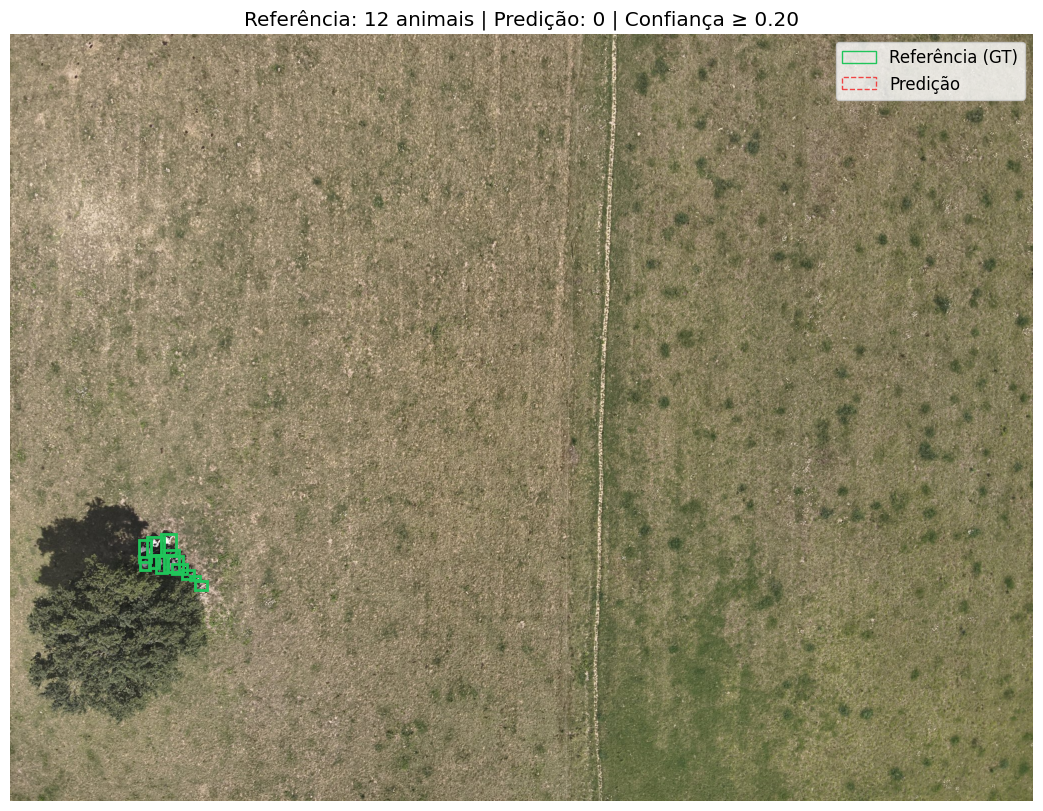

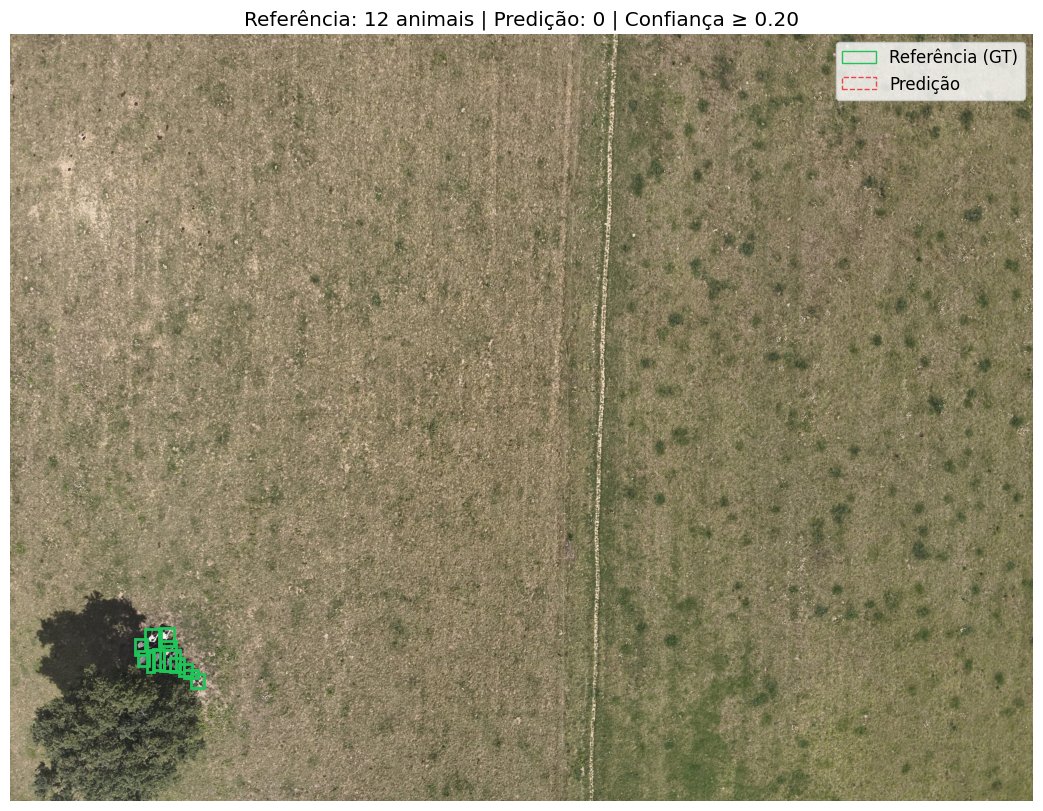

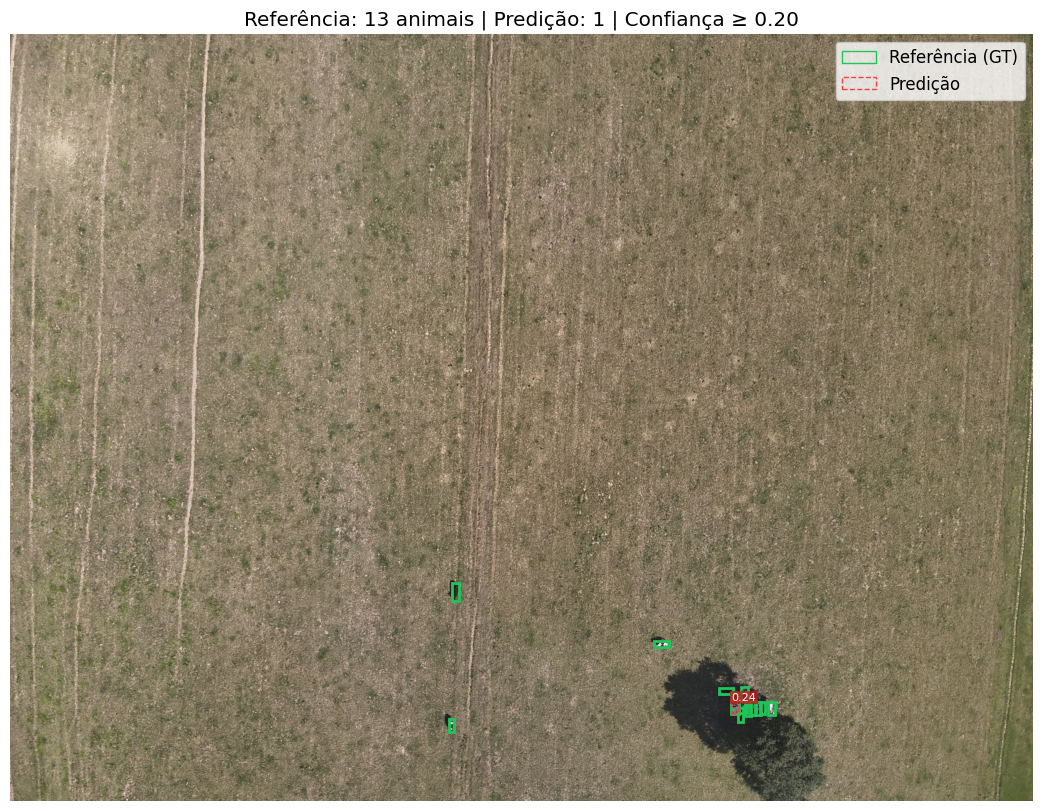

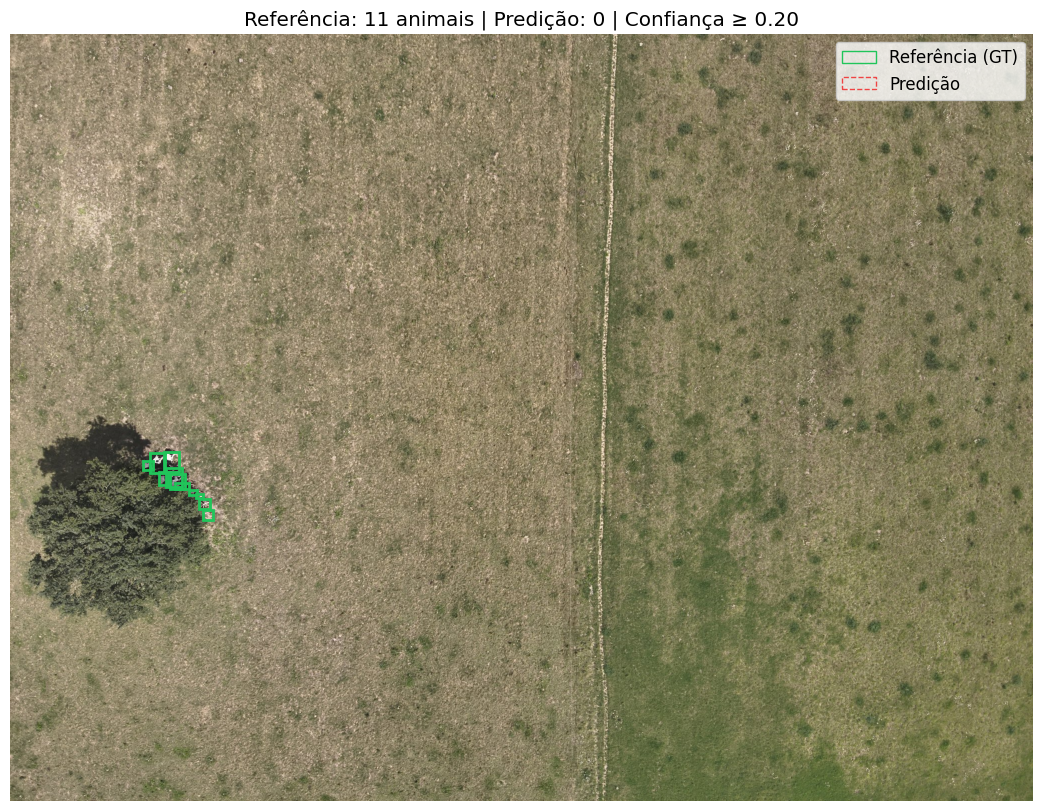

In [14]:
for numero, image_id in enumerate(casos["image_id"]):
    linha = indice[image_id]
    figura = desenhar(linha["image"], linha["gt_boxes"], linha["pred_boxes"],
                      linha["scores"], limiar)
    figura.savefig(SAIDA / "galeria" / f"caso_{numero}.png", dpi=120)
    plt.show()
    plt.close(figura)


## Interpretar o ajuste

Identifique o que mudou e o que permaneceu difícil. Distinga o efeito sobre imagens positivas e negativas, e explique por que sua recomendação pode favorecer o baseline mesmo depois de um treinamento válido.

Preserve `best.pt`, `args.yaml`, `results.csv`, a configuração e o registro de ambiente. No próximo notebook, um checkpoint fixado permitirá estudar o efeito dos recortes sem depender de um treinamento anterior neste runtime.


## Salvar a execução

A pasta de um treinamento concluído é protegida contra reutilização; uma nova tentativa exige outro `name`. Já as pastas de métricas, configurações e figuras têm nomes fixos e são atualizadas ao reexecutar os notebooks. Baixe os resultados **antes de repetir** ou encerrar o runtime.

No Colab, copie o trecho opcional abaixo para uma nova célula e execute-o quando quiser baixar a execução. O ZIP inclui `resultados/` inteiro, os pesos treinados que estiverem nessa pasta e o manifesto. O checkpoint de referência do notebook de recortes continua disponível nos arquivos do projeto e é identificado pelo hash da configuração.

```python
import shutil
from datetime import datetime
from google.colab import files
shutil.copy("assets/manifesto.json", "resultados/manifesto.json")
nome = "resultados-projeto4-" + datetime.now().strftime("%Y%m%d-%H%M%S")
arquivo = shutil.make_archive(nome, "zip", "resultados")
files.download(arquivo)
```

Salve também este notebook com suas saídas em **Arquivo > Salvar** na cópia do Drive, ou use **Arquivo > Fazer download > Fazer download do .ipynb**. A cópia do notebook não salva automaticamente os arquivos temporários do runtime. Localmente, compacte `resultados/` ou use as mesmas linhas sem importar `google.colab` e sem chamar `files.download`.
